In [1]:
import pandas as pd
import numpy as np
import gsw
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import config
from nn_utils.dataset import load_dataset
from utils.plotting import animate_depth_panels, plot_histograms, plot_ts, plot_correlations, plot_profile, plot_boxplots, plot_total_missingness, plot_missingness_over_column
from utils.gridding import df_to_gridded_da

C:\Users\yvjennig\Anaconda3\envs\time_imputation\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
# Load data
df = load_dataset()

output_dir = config.output_dir_plots + "/data_exploration/"
col_name_map = {"LEV_M": "Depth [m]", "LONGITUDE": "Longitude [°]", "LATITUDE": "Latitude [°]", "DATEANDTIME": "Year"}

# Statistics

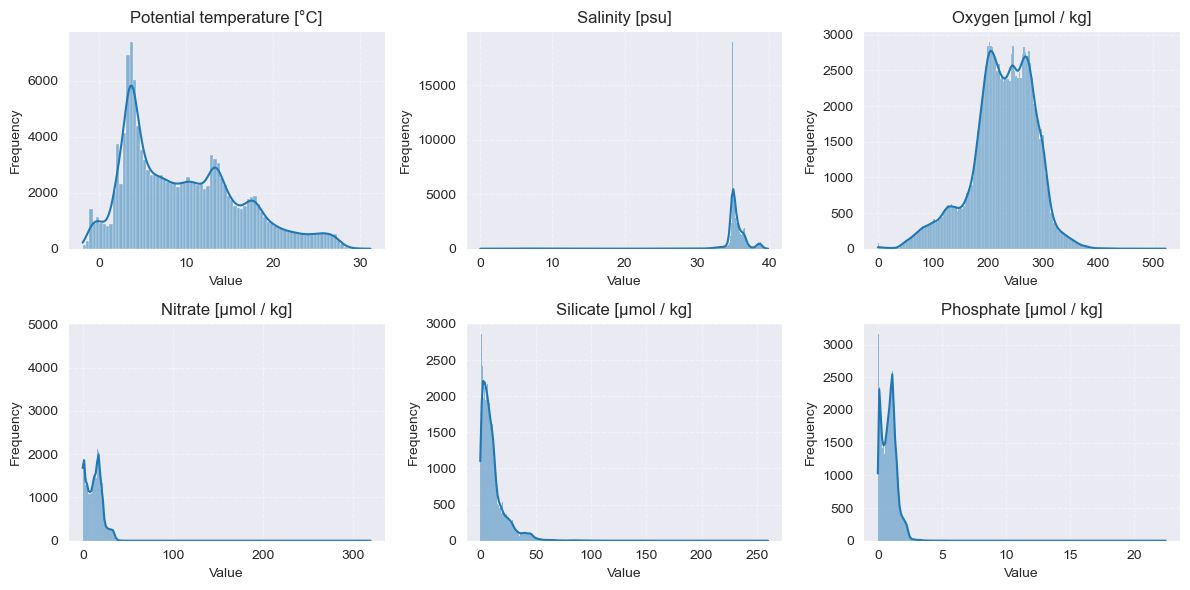

In [3]:
# Data distribution
plot_histograms(df, config, save_as=output_dir + "hist_plot.png")
plt.show()

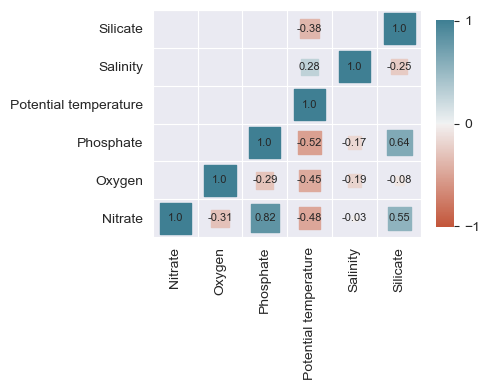

In [4]:
# Correlations
plot_correlations(df, config, save_as=output_dir + "corr_plot.png")

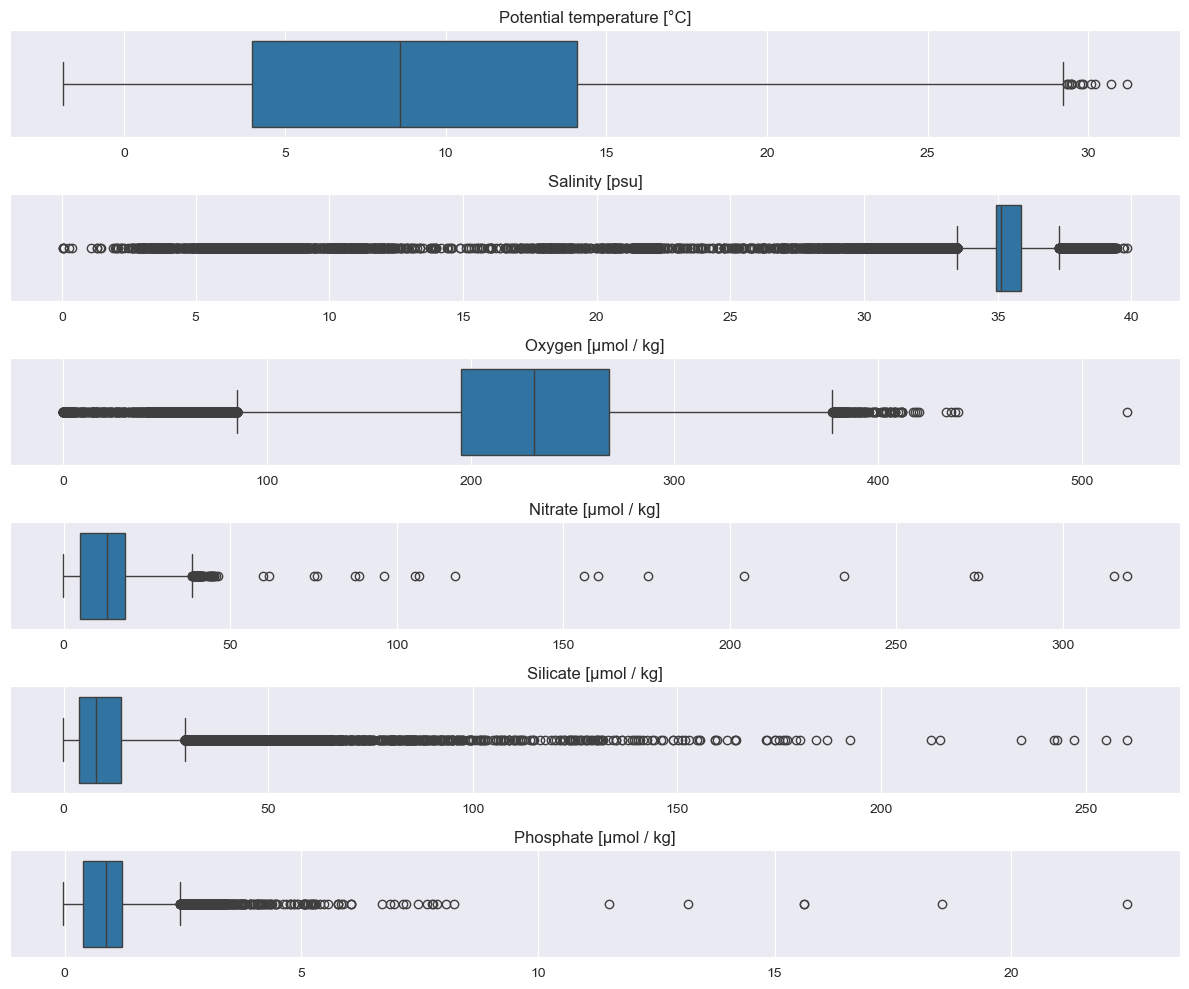

In [5]:
# Boxplots
plot_boxplots(df, config, save_as=output_dir + "boxplot_plot.png", dpi=300)
plt.show()

# Missingness

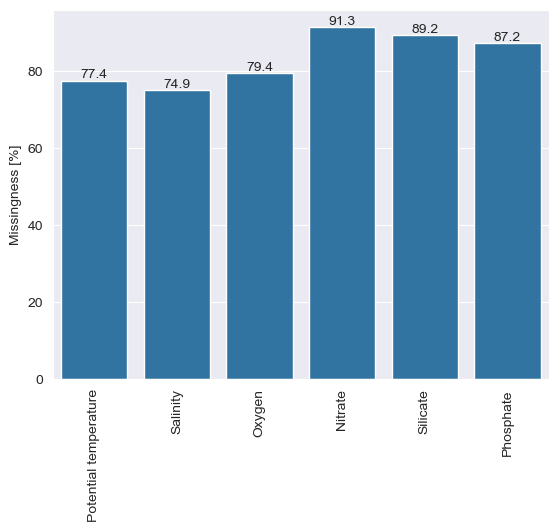

In [6]:
# Total missingness
plot_total_missingness(df, config, save_as=output_dir + "missingness_total.png", dpi=300)
plt.show()

In [7]:
# Correlations
df["missingness"] = df[config.parameters].isna().sum(axis=1) / len(config.parameters) * 100
df.corr()["missingness"].sort_values()  # Strongest is time

DATEANDTIME     -0.540860
LATITUDE        -0.118535
P_OXYGEN        -0.065671
LONGITUDE       -0.060150
P_TEMPERATURE    0.000704
P_SALINITY       0.032163
P_PHOSPHATE      0.038497
LEV_M            0.108614
P_NITRATE        0.119513
P_SILICATE       0.148750
missingness      1.000000
Name: missingness, dtype: float64

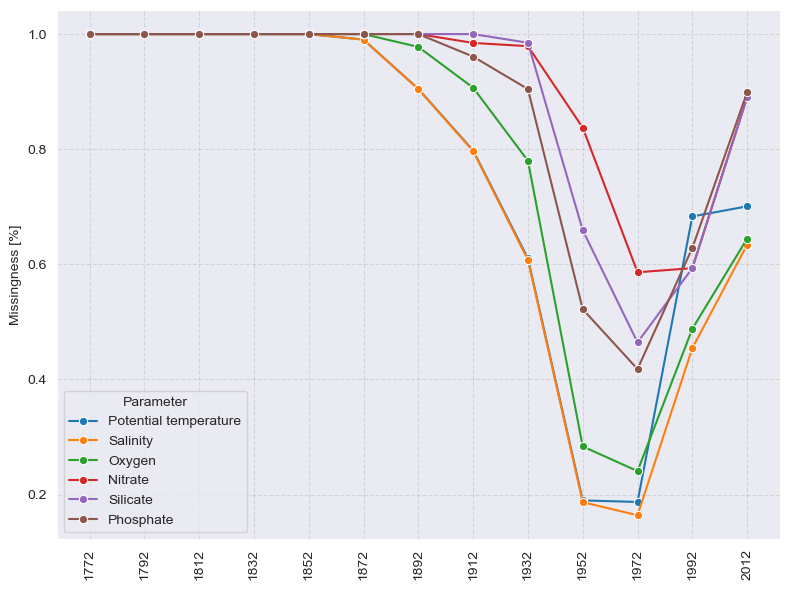

In [8]:
# Missingness over time
plot_missingness_over_column(df, config, col="DATEANDTIME", figsize=(8, 6), save_as=output_dir + "missingness_over_time.png", dpi=300)
plt.show()


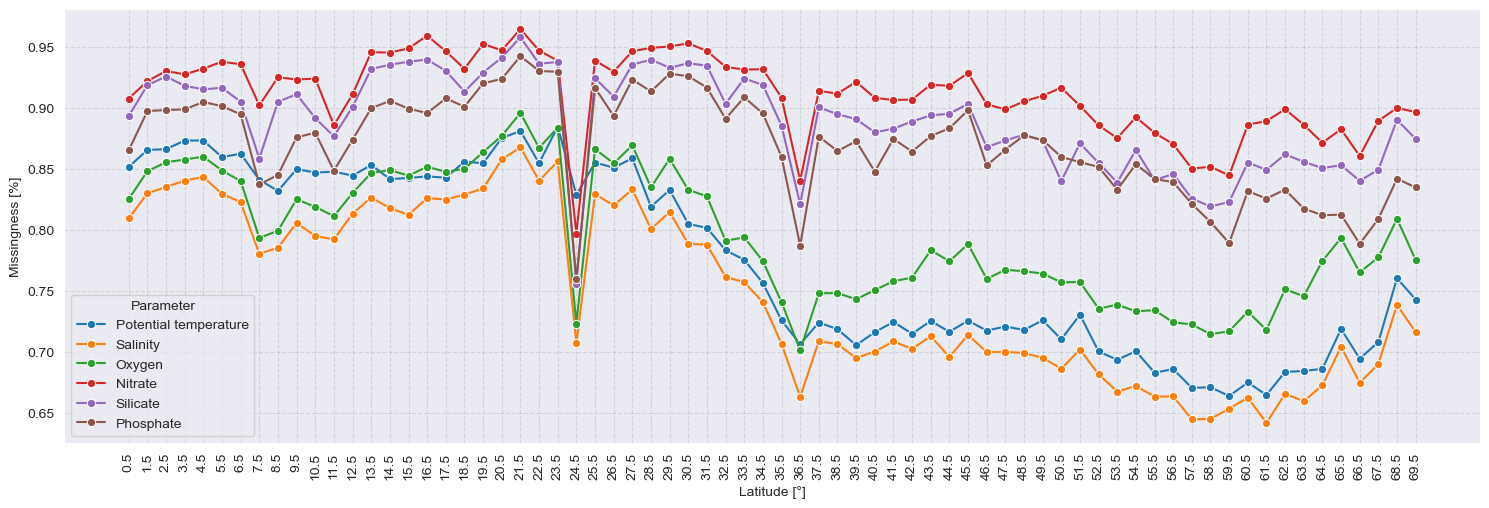

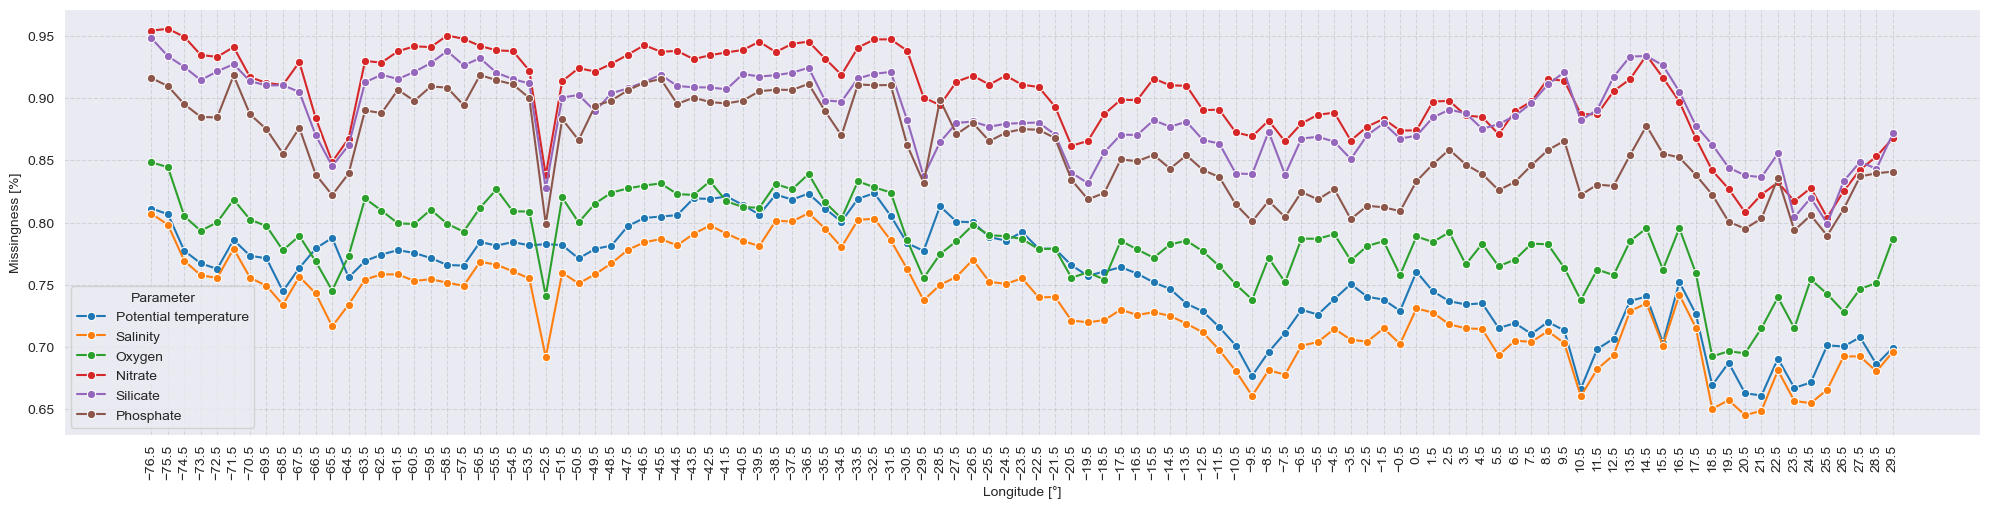

In [11]:
plot_missingness_over_column(df, config, col="LATITUDE", figsize=(15, 5), save_as=output_dir + "missingness_over_latitude.png", dpi=300)
plt.xlabel("Latitude [°]")
plt.show()

plot_missingness_over_column(df, config, col="LONGITUDE", figsize=(20, 5), save_as=output_dir + "missingness_over_longitude.png", dpi=300)
plt.xlabel("Longitude [°]")
plt.show()

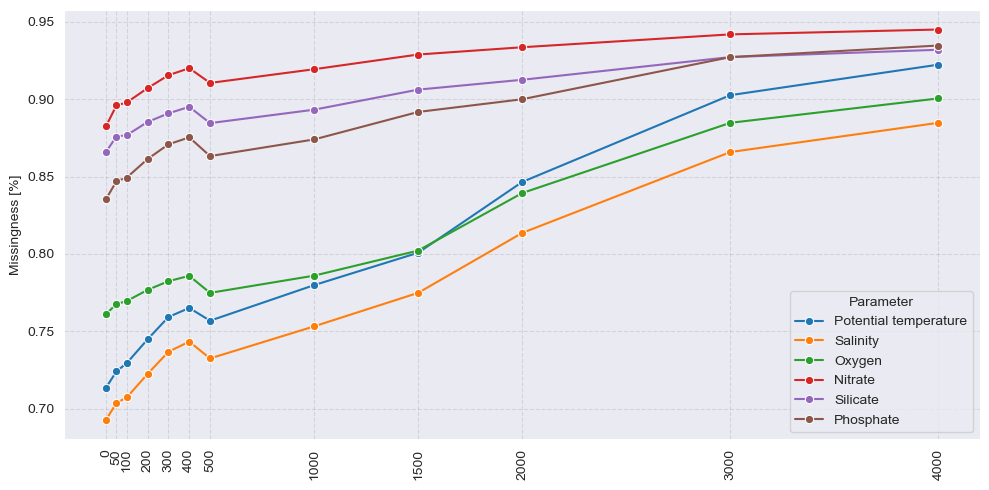

In [15]:
# Missingness over depth
plot_missingness_over_column(df, config, col="LEV_M", figsize=(10, 5), save_as=output_dir + "missingness_over_depth.png", dpi=300)
plt.show()

#  Oceanographic exploration

In [16]:
# General parameter animations
for param in config.parameters:
    save_as = Path(output_dir + f"animation_{param}.mp4")

    if not save_as.exists():
        # Transform to xarray
        ds = df_to_gridded_da(df, value_col=param)

        # Animate and save
        animate_depth_panels(data=ds, save_as=save_as)

In [17]:
# Plot feature density
df["feature_density"] = df[config.parameters].notna().sum(axis=1) / len(config.parameters) * 100

save_as = Path(output_dir + "animation_feature_density.mp4")
if not save_as.exists():
    # Transform to xarray
    ds = df_to_gridded_da(df, value_col="feature_density")

    # Animate and save
    animate_depth_panels(data=ds, save_as=save_as)

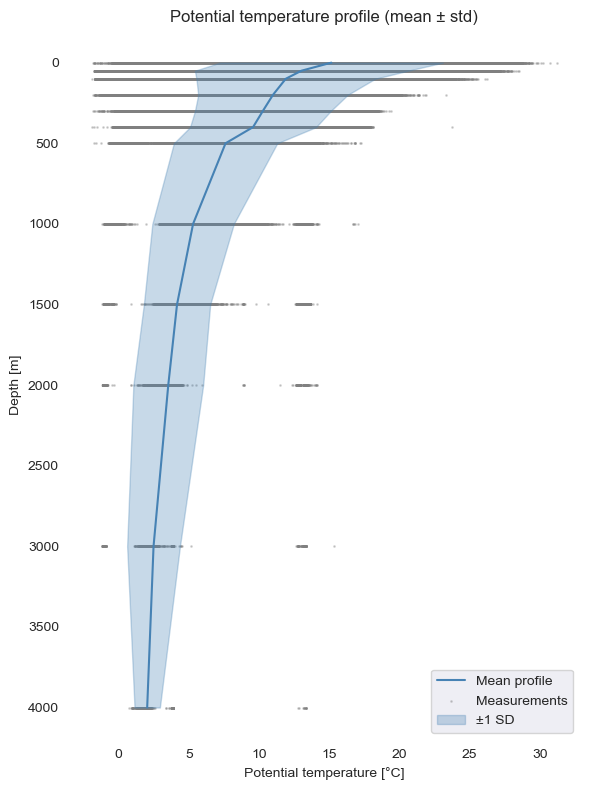

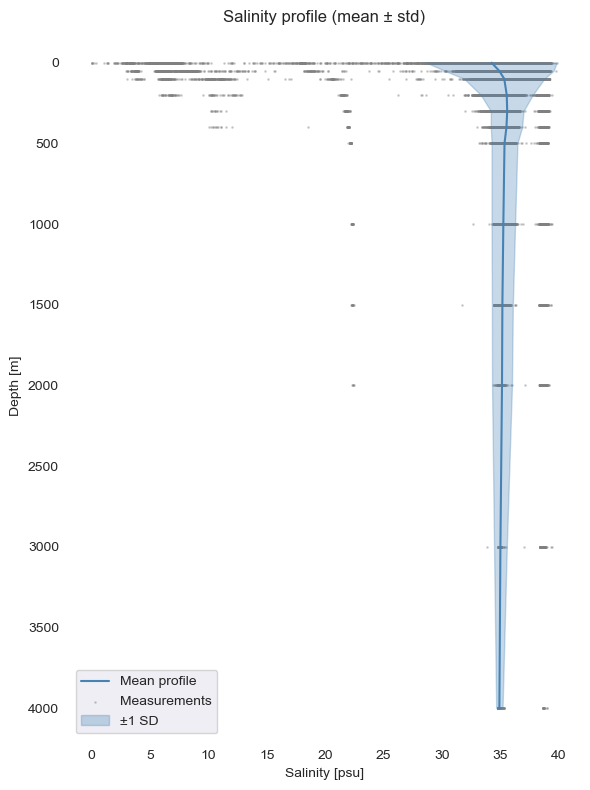

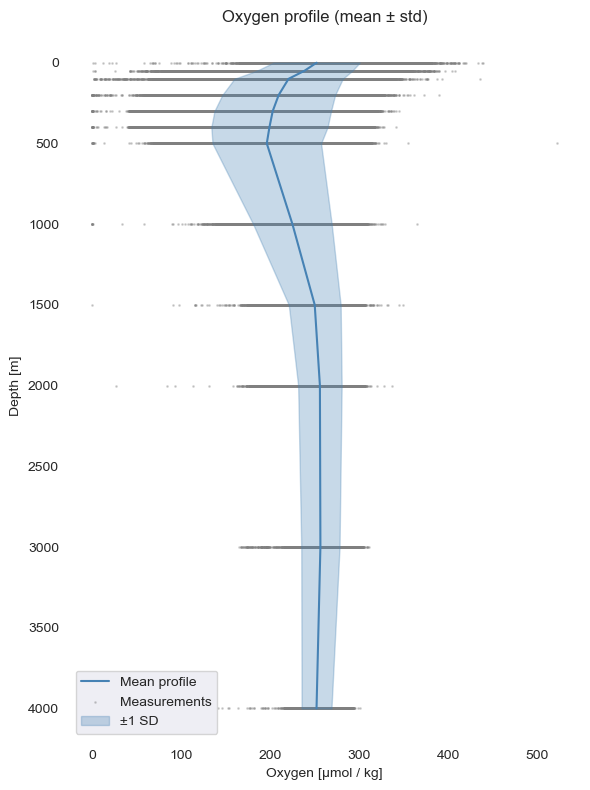

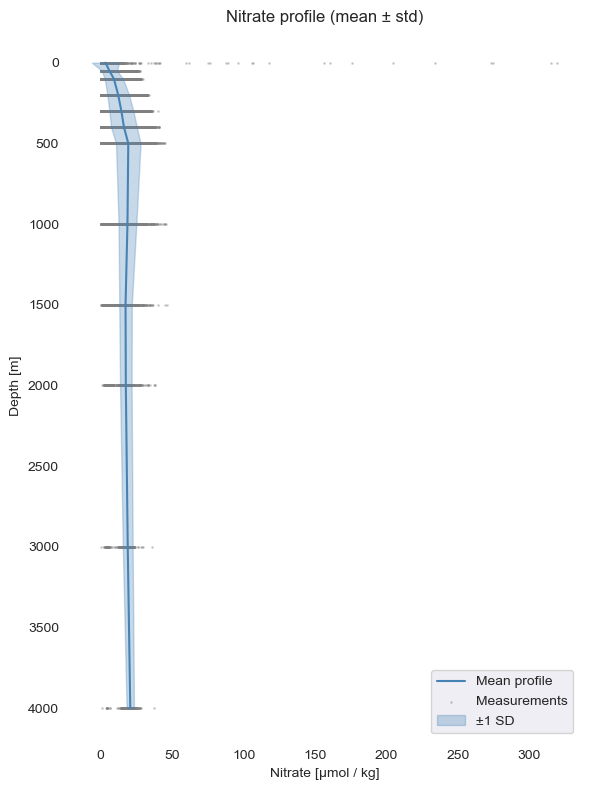

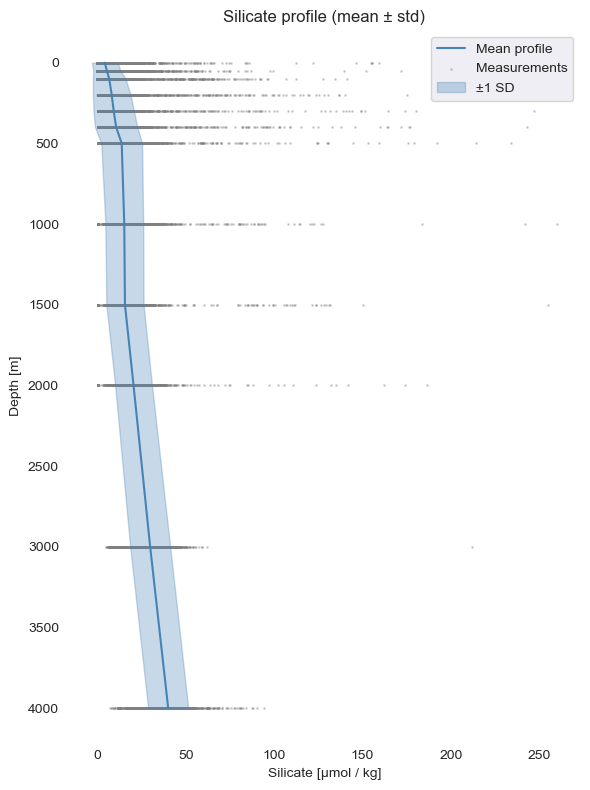

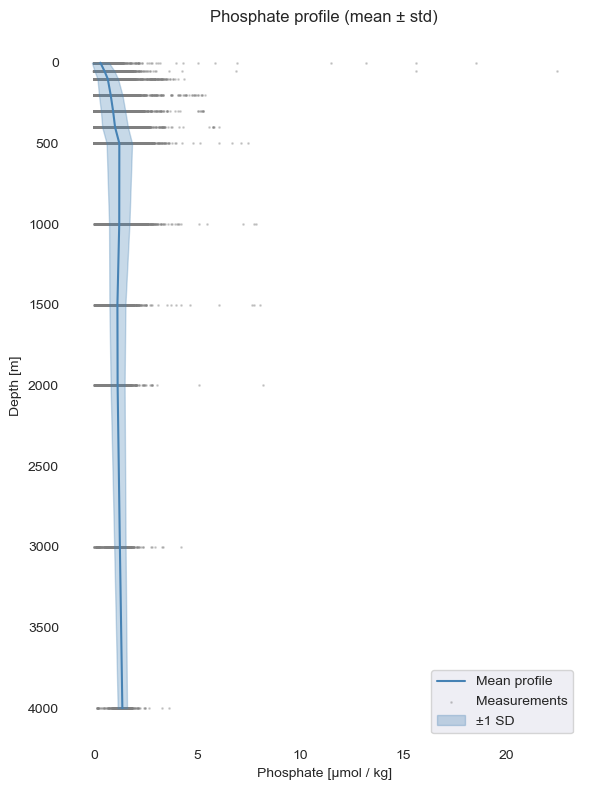

In [18]:
# Depth profiles
for param in config.parameters:
    plot_profile(df, param, save_as=output_dir + "/profiles/profile_" + param + ".png", dpi=300)
    plt.show()

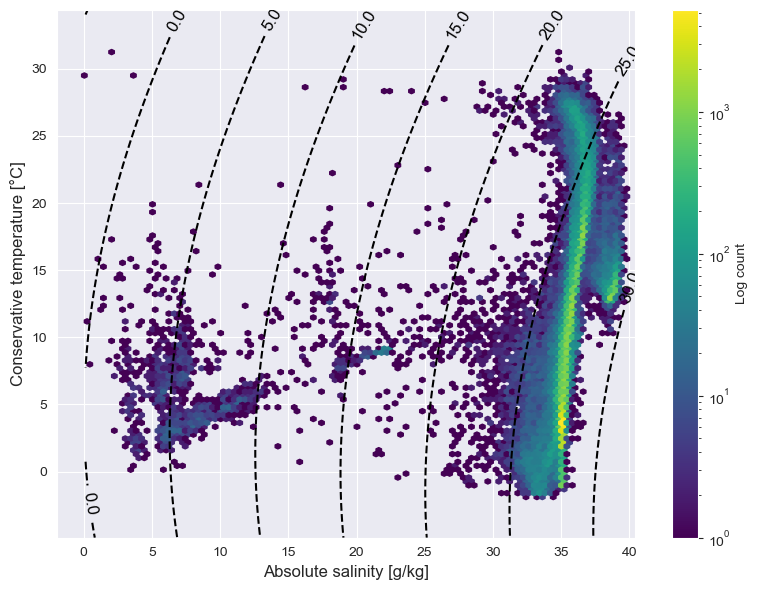

In [19]:
# TS diagram
plot_ts(df, figsize=(8, 6), fontsize=12, save_as=output_dir + "ts.png")